## para colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

RUTA_PROYECTO = "/content/drive/MyDrive/Lab8"  # <-- ajusta si es necesario
os.chdir(RUTA_PROYECTO)
sys.path.insert(0, str(Path(RUTA_PROYECTO) / "scripts"))

# Instalar dependencias (incluye requests porque download_data.py lo usa)
!pip install -q duckdb pandas matplotlib numpy requests

print(f"Directorio: {os.getcwd()}")
print(f"Existe scripts/download_data.py: {Path('scripts/download_data.py').exists()}")
print(f"Existe scripts/consultas.py:     {Path('scripts/consultas.py').exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio: /content/drive/MyDrive/Lab8
Existe scripts/download_data.py: True
Existe scripts/consultas.py:     True


In [4]:
!python scripts/download_data.py


=== YELLOW 2026 ===
  2026-01  descargando...
  2026-01  listo (61.2 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-01.parquet
  2026-02  descargando...
  2026-02  listo (56.0 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-02.parquet
  2026-03  descargando...
  2026-03  listo (64.7 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-03.parquet
  2026-04  descargando...
  2026-04  listo (61.8 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-04.parquet
  2026-05  descargando...
  2026-05  listo (66.5 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-05.parquet
  2026-06  descargando...
  2026-06  listo (62.4 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-06.parquet
  2026-07  descargando...
  2026-07  listo (58.8 MiB) -> /content/drive/MyDrive/Lab8/data/raw/yellow/2026/yellow_tripdata_2026-07.parquet
  2026-08  de

In [5]:
!python scripts/download_data.py --verificar

archivo                                servidor        local  estado
yellow_tripdata_2026-01.parquet      64,165,080   64,165,080  completo
yellow_tripdata_2026-02.parquet      58,683,353   58,683,353  completo
yellow_tripdata_2026-03.parquet      67,891,249   67,891,249  completo
yellow_tripdata_2026-04.parquet      64,818,115   64,818,115  completo
yellow_tripdata_2026-05.parquet      69,699,174   69,699,174  completo
yellow_tripdata_2026-06.parquet      65,465,637   65,465,637  completo
yellow_tripdata_2026-07.parquet      61,685,033   61,685,033  completo
yellow_tripdata_2026-08.parquet      59,043,961   59,043,961  completo
yellow_tripdata_2026-09.parquet               0            0  no publicado
yellow_tripdata_2026-10.parquet               0            0  no publicado
yellow_tripdata_2026-11.parquet               0            0  no publicado
yellow_tripdata_2026-12.parquet               0            0  no publicado
green_tripdata_2026-01.parquet          991,656      991,656  c

In [7]:
from pathlib import Path
print(Path("sql/01_filas_por_archivo.sql").read_text())

-- 01_filas_por_archivo.sql
-- Objetivo: registros, tamanio y programa que escribio cada archivo
-- descargado, leyendo solo el pie de metadatos de cada Parquet.
-- Fuente: data/raw/*/*/*.parquet, directo, sin vistas.
-- Uso: verificacion de completitud (ejercicio 2.7). No recorre los datos, por
-- eso tarda milisegundos aunque los archivos sumen cientos de MB. Un archivo
-- truncado no tiene pie valido y la consulta fallaria al intentar leerlo.
select
    split_part(file_name, '/', -3) as tipo,
    cast(split_part(file_name, '/', -2) as integer) as anio,
    cast(regexp_extract(file_name, '-(\d{2})\.parquet$', 1) as integer) as mes,
    regexp_extract(file_name, '[^/]+$') as archivo,
    num_rows as filas,
    num_row_groups as grupos_de_filas,
    file_size_bytes as bytes,
    created_by as escrito_por
from parquet_file_metadata('data/raw/*/*/*.parquet')
order by tipo desc, anio, mes;



In [8]:
import duckdb
con = duckdb.connect()

# Columnas reales de parquet_file_metadata
print("DuckDB:", duckdb.__version__)
print("\nColumnas de parquet_file_metadata:")
print(con.execute("""
    describe select * from parquet_file_metadata('data/raw/yellow/2026/yellow_tripdata_2026-01.parquet')
""").df().to_string())

DuckDB: 1.3.2

Columnas de parquet_file_metadata:
                   column_name column_type null   key default extra
0                    file_name     VARCHAR  YES  None    None  None
1                   created_by     VARCHAR  YES  None    None  None
2                     num_rows      BIGINT  YES  None    None  None
3               num_row_groups      BIGINT  YES  None    None  None
4               format_version      BIGINT  YES  None    None  None
5         encryption_algorithm     VARCHAR  YES  None    None  None
6  footer_signing_key_metadata     VARCHAR  YES  None    None  None


In [9]:
from pathlib import Path
Path("sql/01_filas_por_archivo.sql").write_text('''-- 01_filas_por_archivo.sql
-- Objetivo: registros y metadatos de cada archivo Parquet, leyendo solo el pie.
-- Fuente: data/raw/*/*/*.parquet, directo, sin vistas.
-- Uso: verificacion de completitud (ejercicio 2.7). No recorre los datos.
-- Nota de compatibilidad: DuckDB 1.3.2 ya no expone file_size_bytes en
-- parquet_file_metadata. El tamanio se obtiene aparte; num_rows > 0 basta
-- para saber que el archivo esta completo.
select
    split_part(file_name, '/', -3) as tipo,
    cast(split_part(file_name, '/', -2) as integer) as anio,
    cast(regexp_extract(file_name, '-(\\d{2})\\.parquet$', 1) as integer) as mes,
    regexp_extract(file_name, '[^/]+$') as archivo,
    num_rows as filas,
    num_row_groups as grupos_de_filas,
    format_version,
    created_by as escrito_por
from parquet_file_metadata('data/raw/*/*/*.parquet')
order by tipo desc, anio, mes;
''')
print("Archivo actualizado.")

Archivo actualizado.


In [10]:
import consultas
con = consultas.conectar()
resultado = consultas.correr(con, "01_filas_por_archivo.sql")
display(resultado)

,tipo,anio,mes,archivo,filas,grupos_de_filas,format_version,escrito_por
0,yellow,2026,1,yellow_tripdata_2026-01.parquet,3724889,4,2,parquet-cpp-arrow version 16.1.0
1,yellow,2026,2,yellow_tripdata_2026-02.parquet,3399866,4,2,parquet-cpp-arrow version 16.1.0
2,yellow,2026,3,yellow_tripdata_2026-03.parquet,3952451,4,2,parquet-cpp-arrow version 16.1.0
3,yellow,2026,4,yellow_tripdata_2026-04.parquet,3831240,4,2,parquet-cpp-arrow version 24.0.0
4,yellow,2026,5,yellow_tripdata_2026-05.parquet,4090836,4,2,parquet-cpp-arrow version 16.1.0
5,yellow,2026,6,yellow_tripdata_2026-06.parquet,3837248,4,2,parquet-cpp-arrow version 21.0.0
6,yellow,2026,7,yellow_tripdata_2026-07.parquet,3530109,4,2,parquet-cpp-arrow version 21.0.0
7,yellow,2026,8,yellow_tripdata_2026-08.parquet,3336716,4,2,parquet-cpp-arrow version 21.0.0
8,green,2026,1,green_tripdata_2026-01.parquet,40272,1,2,parquet-cpp-arrow version 16.1.0
9,green,2026,2,green_tripdata_2026-02.parquet,37373,1,2,parquet-cpp-arrow version 16.1.0


In [12]:
# Celda 1: escribir el archivo scripts/verificar.py
from pathlib import Path

contenido = '''#!/usr/bin/env python3
"""Verifica que los archivos descargados esten completos."""
import sys
from pathlib import Path
import duckdb

RAIZ = Path(__file__).resolve().parent.parent
DIR_RAW = RAIZ / "data" / "raw"

def verificar() -> int:
    con = duckdb.connect()
    con.execute(f"set file_search_path = '{RAIZ}'")
    filas = con.execute("""
        select
            regexp_extract(file_name, '[^/]+$') as archivo,
            split_part(file_name, '/', -3) as tipo,
            cast(split_part(file_name, '/', -2) as integer) as anio,
            num_rows as filas
        from parquet_file_metadata('data/raw/*/*/*.parquet')
        order by tipo, anio, archivo
    """).df()
    filas["bytes"] = filas.apply(
        lambda r: (DIR_RAW / r["tipo"] / str(r["anio"]) / r["archivo"]).stat().st_size,
        axis=1,
    )
    print(f"{'archivo':<40} {'anio':>5} {'filas':>12} {'MiB':>8}")
    print("-" * 70)
    for _, r in filas.iterrows():
        print(f"{r['archivo']:<40} {r['anio']:>5} {r['filas']:>12,} {r['bytes']/1024**2:>8.1f}")
    print("-" * 70)
    print(f"{'TOTAL':<40} {'':>5} {filas['filas'].sum():>12,} {filas['bytes'].sum()/1024**2:>8.1f}")
    problema = filas[(filas["filas"] == 0) | (filas["bytes"] == 0)]
    if not problema.empty:
        print("\\nATENCION: archivos vacios o sin pie valido:")
        print(problema.to_string(index=False))
        return 1
    print("\\nTodos los archivos estan completos.")
    return 0

if __name__ == "__main__":
    sys.exit(verificar())
'''

Path("scripts/verificar.py").write_text(contenido)
print("Creado scripts/verificar.py")

Creado scripts/verificar.py


In [13]:
# Celda 2: ejecutarlo como script (aqui SI existe __file__)
!python scripts/verificar.py

archivo                                   anio        filas      MiB
----------------------------------------------------------------------
green_tripdata_2026-01.parquet            2026       40,272      0.9
green_tripdata_2026-02.parquet            2026       37,373      0.9
green_tripdata_2026-03.parquet            2026       44,208      1.0
green_tripdata_2026-04.parquet            2026       44,238      1.0
green_tripdata_2026-05.parquet            2026       44,921      1.1
green_tripdata_2026-06.parquet            2026       44,163      1.0
green_tripdata_2026-07.parquet            2026       41,252      1.0
green_tripdata_2026-08.parquet            2026       40,687      1.0
yellow_tripdata_2026-01.parquet           2026    3,724,889     61.2
yellow_tripdata_2026-02.parquet           2026    3,399,866     56.0
yellow_tripdata_2026-03.parquet           2026    3,952,451     64.7
yellow_tripdata_2026-04.parquet           2026    3,831,240     61.8
yellow_tripdata_2026-05.parquet 

In [14]:
import consultas
con = consultas.conectar()
display(consultas.correr(con, "01_filas_por_archivo.sql"))  # ahora sin file_size_bytes

,tipo,anio,mes,archivo,filas,grupos_de_filas,format_version,escrito_por
0,yellow,2026,1,yellow_tripdata_2026-01.parquet,3724889,4,2,parquet-cpp-arrow version 16.1.0
1,yellow,2026,2,yellow_tripdata_2026-02.parquet,3399866,4,2,parquet-cpp-arrow version 16.1.0
2,yellow,2026,3,yellow_tripdata_2026-03.parquet,3952451,4,2,parquet-cpp-arrow version 16.1.0
3,yellow,2026,4,yellow_tripdata_2026-04.parquet,3831240,4,2,parquet-cpp-arrow version 24.0.0
4,yellow,2026,5,yellow_tripdata_2026-05.parquet,4090836,4,2,parquet-cpp-arrow version 16.1.0
5,yellow,2026,6,yellow_tripdata_2026-06.parquet,3837248,4,2,parquet-cpp-arrow version 21.0.0
6,yellow,2026,7,yellow_tripdata_2026-07.parquet,3530109,4,2,parquet-cpp-arrow version 21.0.0
7,yellow,2026,8,yellow_tripdata_2026-08.parquet,3336716,4,2,parquet-cpp-arrow version 21.0.0
8,green,2026,1,green_tripdata_2026-01.parquet,40272,1,2,parquet-cpp-arrow version 16.1.0
9,green,2026,2,green_tripdata_2026-02.parquet,37373,1,2,parquet-cpp-arrow version 16.1.0


# Incisos 5-7

In [16]:
import time
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import argparse
import sys
from pathlib import Path

import requests
import consultas

(Path("data/processed/figuras")).mkdir(parents=True, exist_ok=True)

COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}
MESES_ES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
            7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
DIAS_ES = {1:"Lun",2:"Mar",3:"Mie",4:"Jue",5:"Vie",6:"Sab",7:"Dom"}


## 5

In [20]:
# ============================================================
# EJERCICIOS 5, 6 y 7 - Lab 8 DuckDB
# ============================================================
import time
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import consultas

# Aseguramos la carpeta de figuras
(Path("data/processed/figuras")).mkdir(parents=True, exist_ok=True)

COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}
MESES_ES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
            7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
DIAS_ES = {1:"Lun",2:"Mar",3:"Mie",4:"Jue",5:"Vie",6:"Sab",7:"Dom"}

#reescribir download_data.py para soportar varios anios

nuevo_download = '''#!/usr/bin/env python3
"""Descarga los archivos Parquet del NYC TLC Trip Record Data.

Soporta multiples anios (2024 y 2026 para el Ejercicio 5, 2025 para el 8).
Cada archivo existente se omite; solo se descargan los que faltan.

Fuente oficial:
    https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Uso:
    python scripts/download_data.py                    # anios por defecto
    python scripts/download_data.py --anios 2024       # solo 2024
    python scripts/download_data.py --anios 2024 2026
    python scripts/download_data.py --taxi yellow
    python scripts/download_data.py --verificar
"""

import argparse
import sys
from pathlib import Path

import requests

ANIOS = (2024, 2026)   # Ejercicio 8 agregara 2025 aqui
TIPOS_TAXI = ("yellow", "green")
URL_BASE = "https://d37ci6vzurychx.cloudfront.net/trip-data"

RAIZ = Path(__file__).resolve().parent.parent
DIR_DESTINO = RAIZ / "data" / "raw"

URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
RUTA_ZONAS = DIR_DESTINO / "zonas" / "taxi_zone_lookup.csv"

NO_PUBLICADO = (403, 404)
TIEMPO_ESPERA = 60
INTENTOS = 3
BLOQUE = 1024 * 1024
SUFIJO_TEMPORAL = ".part"


def construir_nombre(tipo: str, anio: int, mes: int) -> str:
    return f"{tipo}_tripdata_{anio}-{mes:02d}.parquet"


def construir_url(tipo: str, anio: int, mes: int) -> str:
    return f"{URL_BASE}/{construir_nombre(tipo, anio, mes)}"


def ruta_destino(tipo: str, anio: int, mes: int) -> Path:
    return DIR_DESTINO / tipo / str(anio) / construir_nombre(tipo, anio, mes)


def tamanio_publicado(url: str):
    respuesta = requests.head(url, timeout=TIEMPO_ESPERA, allow_redirects=True)
    if respuesta.status_code in NO_PUBLICADO:
        return None
    respuesta.raise_for_status()
    return int(respuesta.headers.get("Content-Length", 0))


def formato_tamanio(n: float) -> str:
    for unidad in ("B", "KiB", "MiB", "GiB"):
        if n < 1024 or unidad == "GiB":
            return f"{n:.1f} {unidad}"
        n /= 1024
    return f"{n:.1f} GiB"


def descargar_archivo(url: str, destino: Path, esperado: int = 0) -> int:
    destino.parent.mkdir(parents=True, exist_ok=True)
    temporal = destino.with_name(destino.name + SUFIJO_TEMPORAL)
    ultimo_error = None
    for intento in range(1, INTENTOS + 1):
        try:
            with requests.get(url, stream=True, timeout=TIEMPO_ESPERA) as r:
                r.raise_for_status()
                escritos = 0
                with temporal.open("wb") as archivo:
                    for bloque in r.iter_content(chunk_size=BLOQUE):
                        if bloque:
                            archivo.write(bloque)
                            escritos += len(bloque)
            if escritos == 0:
                raise requests.RequestException("servidor devolvio archivo vacio")
            if esperado and escritos != esperado:
                raise requests.RequestException(
                    f"se recibieron {escritos} bytes, servidor anuncia {esperado}"
                )
            temporal.replace(destino)
            return escritos
        except requests.RequestException as error:
            ultimo_error = error
            temporal.unlink(missing_ok=True)
            if intento < INTENTOS:
                print(f"      intento {intento}/{INTENTOS} fallido ({error}); reintentando")
    raise requests.RequestException(f"no se pudo descargar {url}: {ultimo_error}")


def descargar(tipo: str, anio: int) -> dict:
    print(f"\\n=== {tipo.upper()} {anio} ===")
    resumen = {"descargados": 0, "omitidos": 0, "no_publicados": [], "fallidos": []}
    for mes in range(1, 13):
        etiqueta = f"{anio}-{mes:02d}"
        destino = ruta_destino(tipo, anio, mes)
        if destino.exists() and destino.stat().st_size > 0:
            print(f"  {etiqueta}  ya existe, se omite")
            resumen["omitidos"] += 1
            continue
        url = construir_url(tipo, anio, mes)
        try:
            esperado = tamanio_publicado(url)
        except requests.RequestException as error:
            print(f"  {etiqueta}  ERROR al consultar: {error}")
            resumen["fallidos"].append(etiqueta)
            continue
        if esperado is None:
            print(f"  {etiqueta}  aun no publicado por la TLC")
            resumen["no_publicados"].append(etiqueta)
            continue
        print(f"  {etiqueta}  descargando...")
        try:
            escritos = descargar_archivo(url, destino, esperado)
        except requests.RequestException as error:
            print(f"  {etiqueta}  ERROR: {error}")
            resumen["fallidos"].append(etiqueta)
        else:
            print(f"  {etiqueta}  listo ({formato_tamanio(escritos)})")
            resumen["descargados"] += 1
    return resumen


def descargar_zonas() -> str:
    if RUTA_ZONAS.exists() and RUTA_ZONAS.stat().st_size > 0:
        return "ya existe, se omite"
    escritos = descargar_archivo(URL_ZONAS, RUTA_ZONAS, tamanio_publicado(URL_ZONAS) or 0)
    return f"lista ({formato_tamanio(escritos)})"


def verificar(tipo: str, anio: int) -> list:
    filas = []
    for mes in range(1, 13):
        destino = ruta_destino(tipo, anio, mes)
        local = destino.stat().st_size if destino.exists() else 0
        remoto = tamanio_publicado(construir_url(tipo, anio, mes))
        if remoto is None:
            estado = "no publicado"
        elif local == 0:
            estado = "falta"
        elif local == remoto:
            estado = "completo"
        else:
            estado = "incompleto"
        filas.append({
            "tipo": tipo, "anio": anio, "mes": mes, "archivo": destino.name,
            "bytes_servidor": remoto or 0, "bytes_local": local, "estado": estado,
        })
    return filas


def imprimir_verificacion(tipos: tuple, anios: tuple) -> int:
    pendientes = 0
    print(f"{'archivo':<34} {'servidor':>12} {'local':>12}  estado")
    for anio in anios:
        for tipo in tipos:
            for fila in verificar(tipo, anio):
                print(f"{fila['archivo']:<34} {fila['bytes_servidor']:>12,} "
                      f"{fila['bytes_local']:>12,}  {fila['estado']}")
                if fila["estado"] in ("falta", "incompleto"):
                    pendientes += 1
    print(f"\\nmeses publicados sin archivo completo en disco: {pendientes}")
    return 1 if pendientes else 0


def main() -> int:
    parser = argparse.ArgumentParser(description="Descarga los datos de taxis del NYC TLC.")
    parser.add_argument("--taxi", choices=(*TIPOS_TAXI, "all"), default="all")
    parser.add_argument("--anios", type=int, nargs="+", default=list(ANIOS))
    parser.add_argument("--verificar", action="store_true")
    args = parser.parse_args()

    tipos = TIPOS_TAXI if args.taxi == "all" else (args.taxi,)
    anios = tuple(args.anios)

    if args.verificar:
        return imprimir_verificacion(tipos, anios)

    total = {"descargados": 0, "omitidos": 0, "no_publicados": [], "fallidos": []}
    for anio in anios:
        for tipo in tipos:
            resumen = descargar(tipo, anio)
            total["descargados"] += resumen["descargados"]
            total["omitidos"] += resumen["omitidos"]
            total["no_publicados"] += [f"{tipo} {m}" for m in resumen["no_publicados"]]
            total["fallidos"] += [f"{tipo} {m}" for m in resumen["fallidos"]]

    try:
        print(f"\\nTabla de zonas: {descargar_zonas()}")
    except requests.RequestException as error:
        print(f"\\nTabla de zonas: ERROR {error}")
        total["fallidos"].append("zonas")

    print("\\n" + "=" * 60)
    print("RESUMEN")
    print("=" * 60)
    print(f"  descargados   : {total['descargados']}")
    print(f"  ya existian   : {total['omitidos']}")
    print(f"  no publicados : {len(total['no_publicados'])}")
    if total["no_publicados"]:
        print(f"      {', '.join(total['no_publicados'])}")
    print(f"  fallidos      : {len(total['fallidos'])}")
    if total["fallidos"]:
        print(f"      {', '.join(total['fallidos'])}")
    print("=" * 60)
    return 1 if total["fallidos"] else 0


if __name__ == "__main__":
    sys.exit(main())
'''

Path("scripts/download_data.py").write_text(nuevo_download)
print("scripts/download_data.py actualizado (2024-2026)")

scripts/download_data.py actualizado (2024-2026)


In [22]:
#DOWLAD 2024 2026 ya esta
!python scripts/download_data.py --anios 2024
!python scripts/download_data.py --verificar


=== YELLOW 2024 ===
  2024-01  ya existe, se omite
  2024-02  ya existe, se omite
  2024-03  ya existe, se omite
  2024-04  ya existe, se omite
  2024-05  ya existe, se omite
  2024-06  ya existe, se omite
  2024-07  ya existe, se omite
  2024-08  ya existe, se omite
  2024-09  ya existe, se omite
  2024-10  ya existe, se omite
  2024-11  ya existe, se omite
  2024-12  ya existe, se omite

=== GREEN 2024 ===
  2024-01  ya existe, se omite
  2024-02  ya existe, se omite
  2024-03  ya existe, se omite
  2024-04  ya existe, se omite
  2024-05  ya existe, se omite
  2024-06  ya existe, se omite
  2024-07  ya existe, se omite
  2024-08  ya existe, se omite
  2024-09  ya existe, se omite
  2024-10  ya existe, se omite
  2024-11  ya existe, se omite
  2024-12  ya existe, se omite

Tabla de zonas: ya existe, se omite

RESUMEN
  descargados   : 0
  ya existian   : 24
  no publicados : 0
  fallidos      : 0
archivo                                servidor        local  estado
yellow_tripdata_202

In [24]:
#validacion y comparacion

#validacion (solo enero-agosto)
Path("sql/04_comparacion_mensual.sql").write_text('''-- 04_comparacion_mensual.sql
-- Objetivo: viajes por dia de cada mes, 2024 y 2026, por tipo (5).
-- Fuente: data/raw/*/*/*.parquet, directo.
-- Se restringe a enero-agosto porque 2026 solo tiene esos meses publicados.
select
    split_part(filename, '/', -3) as tipo,
    split_part(filename, '/', -2) as anio,
    cast(extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as mes,
    count(*) / any_value(
        extract(day from last_day(coalesce(tpep_pickup_datetime, lpep_pickup_datetime)))
    ) as viajes_por_dia
from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
where split_part(filename, '/', -2) in ('2024', '2026')
  and extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) between 1 and 8
group by tipo, anio, mes
order by tipo desc, mes, anio;
''')

# Lo mismo para el indice
Path("sql/04_indice_mensual.sql").write_text('''-- 04_indice_mensual.sql
-- Objetivo: viajes por dia de 2026 como indice con el mismo mes de 2024 = 100.
-- Fuente: data/raw/*/{2024,2026}/*.parquet, directo.
-- Se restringe a enero-agosto.
with mensual as (
    select
        split_part(filename, '/', -3) as tipo,
        split_part(filename, '/', -2) as anio,
        cast(extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as mes,
        count(*) / any_value(
            extract(day from last_day(coalesce(tpep_pickup_datetime, lpep_pickup_datetime)))
        ) as viajes_por_dia
    from read_parquet('data/raw/*/*/*.parquet', union_by_name = true, filename = true)
    where split_part(filename, '/', -2) in ('2024', '2026')
      and extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) between 1 and 8
    group by tipo, anio, mes
)
select
    m.tipo,
    m.anio,
    m.mes,
    m.viajes_por_dia,
    100.0 * m.viajes_por_dia / b.viajes_por_dia as indice_2024_100
from mensual m
join mensual b on m.tipo = b.tipo and m.mes = b.mes and b.anio = '2024'
order by m.tipo desc, m.mes, m.anio;
''')

print("[OK] Consultas corregidas: solo enero-agosto.")

con = consultas.conectar()
print("\n=== Validar anios (ahora tambien muestra cuantos meses tiene cada anio) ===")
Path("sql/04_validar_anios.sql").write_text('''-- 04_validar_anios.sql
-- Objetivo: comprobar que DuckDB ve los archivos de 2024 y 2026 juntos (5.6).
-- Fuente: data/raw/*/*/*.parquet, directo.
select
    split_part(file_name, '/', -3) as tipo,
    split_part(file_name, '/', -2) as anio,
    count(*) as archivos,
    min(regexp_extract(file_name, '(\\\\d{4}-\\\\d{2})\\\\.parquet$', 1)) as primer_mes,
    max(regexp_extract(file_name, '(\\\\d{4}-\\\\d{2})\\\\.parquet$', 1)) as ultimo_mes,
    sum(num_rows) as registros
from parquet_file_metadata('data/raw/*/*/*.parquet')
group by tipo, anio
order by tipo desc, anio;
''')
display(consultas.correr(con, "04_validar_anios.sql"))

print("\n=== Comparacion mensual (solo enero-agosto) ===")
display(consultas.correr(con, "04_comparacion_mensual.sql"))

print("\n=== Indice 2024 = 100 ===")
display(consultas.correr(con, "04_indice_mensual.sql"))

[OK] Consultas corregidas: solo enero-agosto.

=== Validar anios (ahora tambien muestra cuantos meses tiene cada anio) ===


,tipo,anio,archivos,primer_mes,ultimo_mes,registros
0,yellow,2024,12,,,41169720.0
1,yellow,2026,8,,,29703355.0
2,green,2024,12,,,660218.0
3,green,2026,8,,,337114.0



=== Comparacion mensual (solo enero-agosto) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,tipo,anio,mes,viajes_por_dia
0,yellow,2024,1,95633.451613
1,yellow,2026,1,120158.096774
2,yellow,2024,2,103708.068966
3,yellow,2026,2,121423.785714
4,yellow,2024,3,115568.161290
5,yellow,2026,3,127498.161290
6,yellow,2024,4,117143.166667
7,yellow,2026,4,127708.533333
8,yellow,2024,5,120123.967742
9,yellow,2026,5,131962.064516



=== Indice 2024 = 100 ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,tipo,anio,mes,viajes_por_dia,indice_2024_100
0,yellow,2024,1,95633.451613,100.000000
1,yellow,2026,1,120158.096774,125.644421
2,yellow,2024,2,103708.068966,100.000000
3,yellow,2026,2,121423.785714,117.082294
4,yellow,2024,3,115568.161290,100.000000
5,yellow,2026,3,127498.161290,110.322912
6,yellow,2024,4,117143.166667,100.000000
7,yellow,2026,4,127708.533333,109.019192
8,yellow,2024,5,120123.967742,100.000000
9,yellow,2026,5,131962.064516,109.854900


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

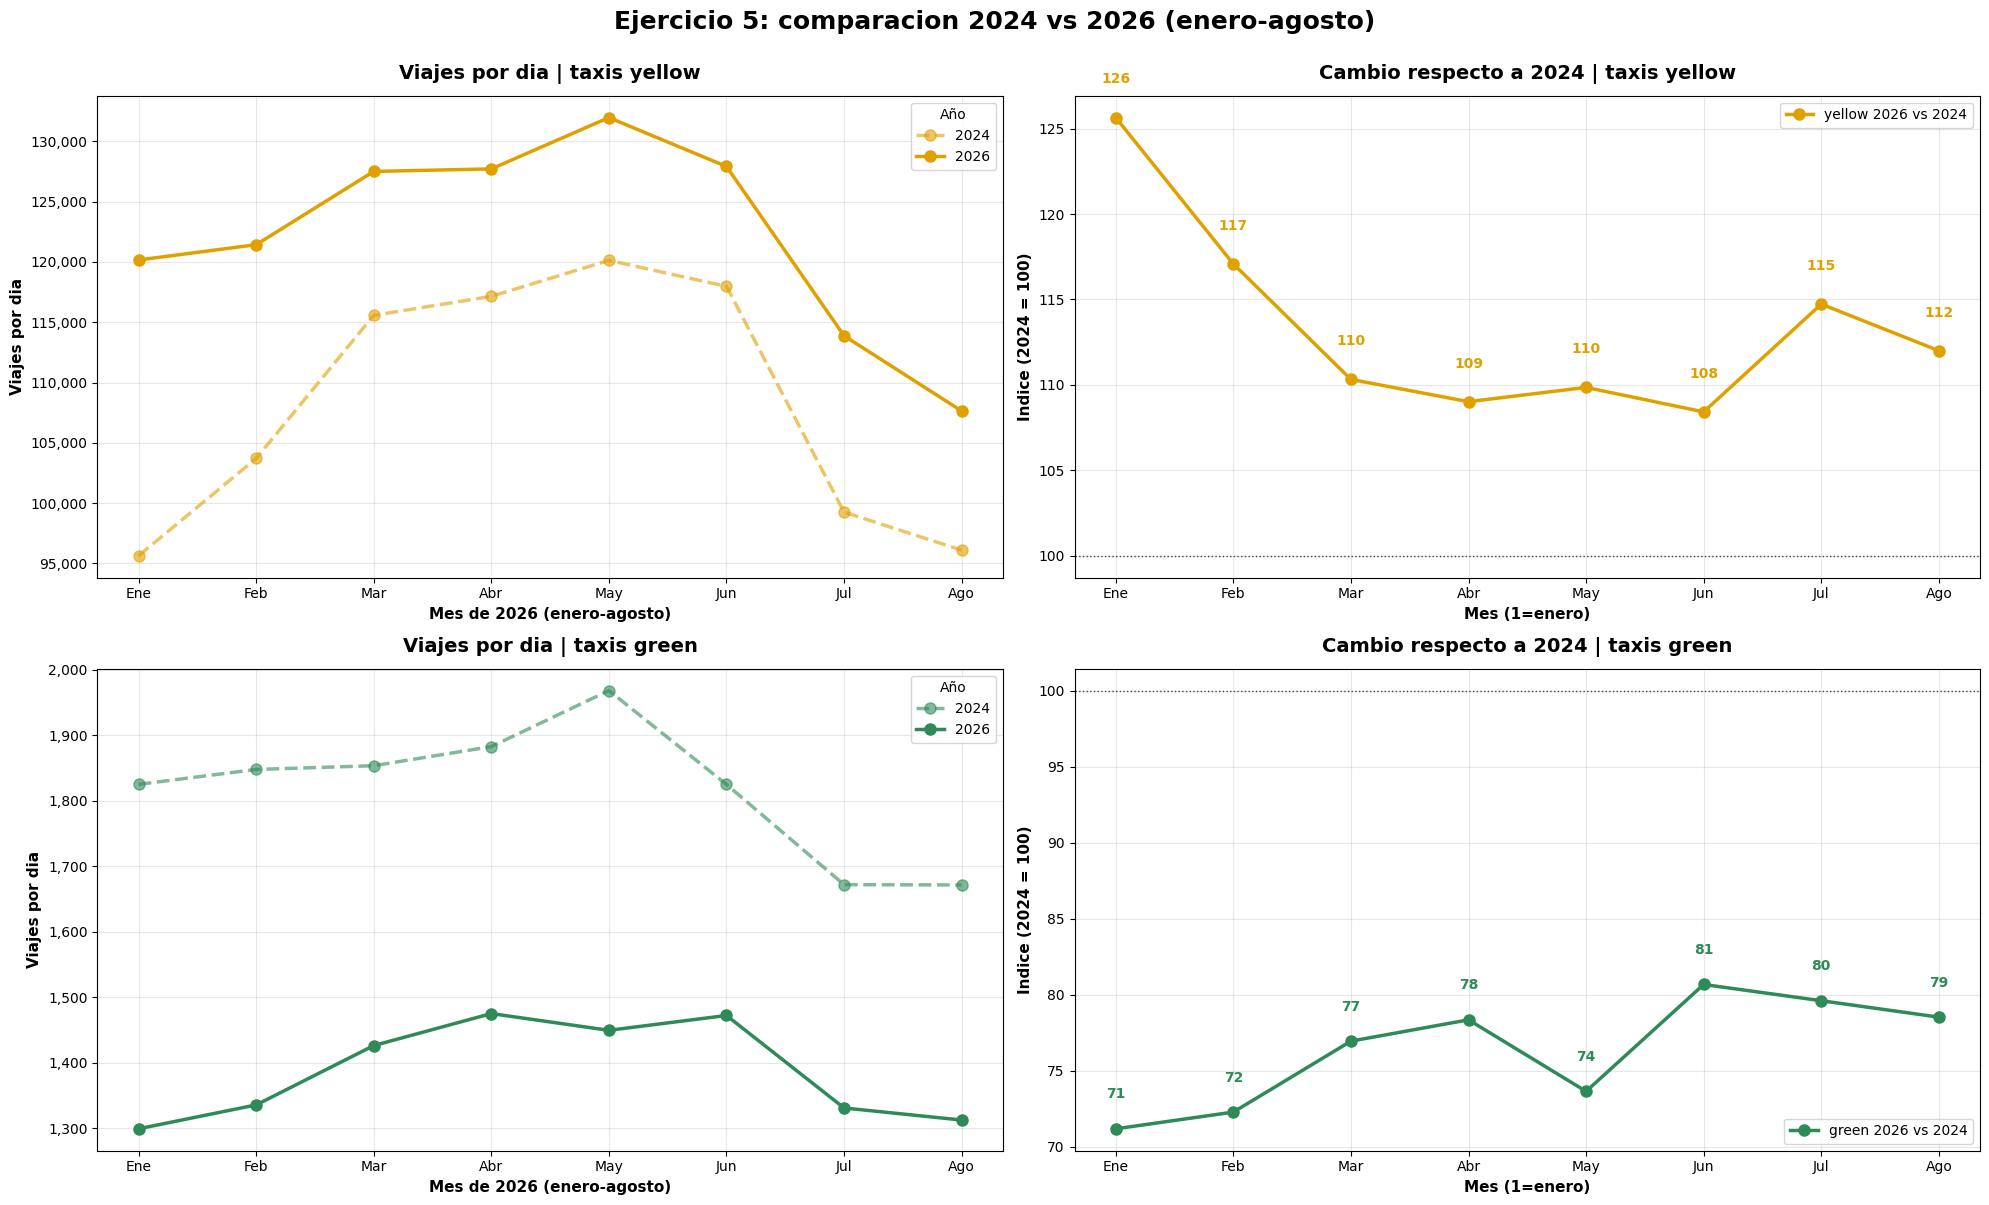


=== Cambio porcentual 2026 vs 2024 (mes y tipo) ===


tipo,green,yellow
Ene,-28.8,25.6
Feb,-27.7,17.1
Mar,-23.1,10.3
Abr,-21.7,9.0
May,-26.4,9.9
Jun,-19.3,8.4
Jul,-20.4,14.7
Ago,-21.5,12.0



=== Cambio promedio 2026 vs 2024 (enero-agosto) ===
  yellow  : +13.4% en promedio (min +8.4%, max +25.6%)
  green   : -23.6% en promedio (min -28.8%, max -19.3%)


In [27]:
from matplotlib.ticker import FuncFormatter

COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}
MESES_ES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",7:"Jul",8:"Ago"}

#graficas en folder
(Path("data/processed/figuras")).mkdir(parents=True, exist_ok=True)

con = consultas.conectar()

comparacion = consultas.correr(con, "04_comparacion_mensual.sql")
indice = consultas.correr(con, "04_indice_mensual.sql")


def graficar_comparacion_anual(comparacion, indice):
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    for i, tipo in enumerate(["yellow", "green"]):
        # --- Panel izquierdo: viajes por dia ---
        ax_izq = axes[i, 0]
        datos = comparacion[comparacion["tipo"] == tipo]
        for anio, estilo, alpha in [("2024", "--", 0.6), ("2026", "-", 1.0)]:
            d = datos[datos["anio"].astype(str) == anio].sort_values("mes")
            ax_izq.plot(d["mes"], d["viajes_por_dia"], estilo,
                        color=COLOR_TAXI[tipo], linewidth=2.5, marker="o",
                        markersize=8, alpha=alpha, label=anio)
        ax_izq.set_xticks(range(1, 9), [MESES_ES[m] for m in range(1, 9)])
        ax_izq.set_title(f"Viajes por dia | taxis {tipo}",
                         fontsize=14, fontweight="bold", pad=12)
        ax_izq.set_xlabel("Mes de 2026 (enero-agosto)", fontsize=11, fontweight="bold")
        ax_izq.set_ylabel("Viajes por dia", fontsize=11, fontweight="bold")
        ax_izq.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax_izq.grid(alpha=0.3)
        ax_izq.legend(title="Año", fontsize=10)

        # --- Panel derecho: indice 2024=100 ---
        ax_der = axes[i, 1]
        d_idx = indice[(indice["tipo"] == tipo) & (indice["anio"].astype(str) == "2026")].sort_values("mes")
        ax_der.plot(d_idx["mes"], d_idx["indice_2024_100"], "-",
                    color=COLOR_TAXI[tipo], linewidth=2.5, marker="o",
                    markersize=8, label=f"{tipo} 2026 vs 2024")
        ax_der.axhline(100, color="#444444", linestyle=":", linewidth=1)
        for _, r in d_idx.iterrows():
            ax_der.text(r["mes"], r["indice_2024_100"] + 2,
                        f"{r['indice_2024_100']:.0f}",
                        ha="center", fontsize=10, fontweight="bold",
                        color=COLOR_TAXI[tipo])
        ax_der.set_xticks(range(1, 9), [MESES_ES[m] for m in range(1, 9)])
        ax_der.set_title(f"Cambio respecto a 2024 | taxis {tipo}",
                         fontsize=14, fontweight="bold", pad=12)
        ax_der.set_xlabel("Mes (1=enero)", fontsize=11, fontweight="bold")
        ax_der.set_ylabel("Indice (2024 = 100)", fontsize=11, fontweight="bold")
        ax_der.grid(alpha=0.3)
        ax_der.legend(fontsize=10)

    fig.suptitle("Ejercicio 5: comparacion 2024 vs 2026 (enero-agosto)",
                 fontsize=18, fontweight="bold", y=1.00)
    fig.tight_layout()
    fig.savefig("data/processed/figuras/04_comparacion_2024_2026.png",
                bbox_inches="tight", dpi=110)
    return fig, axes


fig, _ = graficar_comparacion_anual(comparacion, indice)
plt.show()

#tabla resumen
print("\n=== Cambio porcentual 2026 vs 2024 (mes y tipo) ===")
pivote = indice.pivot_table(
    index=["tipo", "mes"], columns="anio", values="viajes_por_dia"
).reset_index()
pivote.columns.name = None
pivote["cambio_pct"] = 100 * (pivote["2026"] / pivote["2024"] - 1)
tabla_cambio = pivote.pivot(index="mes", columns="tipo", values="cambio_pct").round(1)
tabla_cambio.index = [MESES_ES[m] for m in tabla_cambio.index]
display(tabla_cambio)

# --- Promedios por tipo ---
print("\n=== Cambio promedio 2026 vs 2024 (enero-agosto) ===")
for tipo in ["yellow", "green"]:
    d = pivote[pivote["tipo"] == tipo]
    print(f"  {tipo:8s}: {d['cambio_pct'].mean():+.1f}% en promedio "
          f"(min {d['cambio_pct'].min():+.1f}%, max {d['cambio_pct'].max():+.1f}%)")

## 6

In [ ]:
RAIZ = Path.cwd()
(RAIZ / "data" / "processed").mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute(f"set file_search_path = '{RAIZ}'")

REPETICIONES = 5


def medir(sql, repeticiones=REPETICIONES):#-tiempo
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        con.execute(sql).fetchall()
        tiempos.append(time.perf_counter() - inicio)
    return min(tiempos)


# consutlas
CONSULTAS = {
    "conteo_por_mes": """
        select tipo, anio, mes, count(*) as viajes
        from {fuente}
        group by tipo, anio, mes
        order by tipo, anio, mes
    """,
    "distancia_mediana": """
        select tipo, anio, median(trip_distance) as dist_mediana
        from {fuente}
        group by tipo, anio
        order by tipo, anio
    """,
    "pago_mas_usado": """
        select tipo, anio, payment_type, count(*) as viajes
        from {fuente}
        group by tipo, anio, payment_type
        order by tipo, anio, viajes desc
    """,
    "velocidad_por_hora": """
        select tipo, anio, hora,
               median(trip_distance / (duracion_min / 60)) as vel_mediana
        from {fuente}
        where duracion_min > 0 and duracion_min < 24*60
          and trip_distance > 0 and trip_distance < 100
        group by tipo, anio, hora
        order by tipo, anio, hora
    """,
}


def preparar_vista_parquet(patron_glob):
    #vista temporal
    con.execute(f"""
        create or replace temp view vista_parquet as
        select
            split_part(filename, '/', -3) as tipo,
            split_part(filename, '/', -2) as anio,
            cast(extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as mes,
            cast(extract(hour from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as hora,
            trip_distance,
            payment_type,
            case when date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) > 0
                 then date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0
                 else 0 end as duracion_min
        from read_parquet('{patron_glob}', union_by_name = true, filename = true)
    """)


def preparar_tabla_materializada(patron_glob, nombre_tabla):
    inicio = time.perf_counter()
    con.execute(f"""
        create or replace table {nombre_tabla} as
        select
            split_part(filename, '/', -3) as tipo,
            split_part(filename, '/', -2) as anio,
            cast(extract(month from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as mes,
            cast(extract(hour from coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) as integer) as hora,
            trip_distance,
            payment_type,
            case when date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) > 0
                 then date_diff('second',
                     coalesce(tpep_pickup_datetime, lpep_pickup_datetime),
                     coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0
                 else 0 end as duracion_min
        from read_parquet('{patron_glob}', union_by_name = true, filename = true)
    """)
    tiempo = time.perf_counter() - inicio
    n = con.execute(f"select count(*) from {nombre_tabla}").fetchone()[0]
    return tiempo, n


def benchmark(patron_glob, nombre_tabla, etiqueta):
    #todas las consultas y dataframe
    print(f"\n{'=' * 60}")
    print(f"Escenario: {etiqueta}")
    print(f"{'=' * 60}")

    print("  Preparando vista Parquet...")
    preparar_vista_parquet(patron_glob)

    print("  Materializando tabla DuckDB...")
    t_carga, n = preparar_tabla_materializada(patron_glob, nombre_tabla)
    print(f"    {n:,} filas cargadas en {t_carga:.2f} s")

    filas = []
    for nombre, plantilla in CONSULTAS.items():
        print(f"  Midiendo: {nombre}...")
        sql_parquet = plantilla.format(fuente="vista_parquet")
        sql_tabla = plantilla.format(fuente=nombre_tabla)

        t_parquet = medir(sql_parquet)
        t_tabla = medir(sql_tabla)

        filas.append({
            "escenario": etiqueta,
            "consulta": nombre,
            "parquet_ms": round(t_parquet * 1000, 1),
            "tabla_ms": round(t_tabla * 1000, 1),
            "veces_mas_rapido": round(t_parquet / t_tabla, 2),
        })

    return filas, t_carga, n


#pruebas
resultados = []
resumen_carga = []

#solo 2026
filas_2026, t_carga, n = benchmark(
    patron_glob="data/raw/*/2026/*.parquet",
    nombre_tabla="viajes_2026",
    etiqueta="solo_2026",
)
resultados.extend(filas_2026)
resumen_carga.append({"escenario": "solo_2026", "filas": n, "carga_s": round(t_carga, 2)})

#2024 + 2026
filas_ambos, t_carga, n = benchmark(
    patron_glob="data/raw/*/*/*.parquet",
    nombre_tabla="viajes_ambos",
    etiqueta="2024_y_2026",
)
resultados.extend(filas_ambos)
resumen_carga.append({"escenario": "2024_y_2026", "filas": n, "carga_s": round(t_carga, 2)})


df_bench = pd.DataFrame(resultados)
df_bench.to_csv("data/processed/benchmark.csv", index=False)

print("\n" + "=" * 60)
print("TABLA BENCHMARK")
print("=" * 60)
print(df_bench.to_string(index=False))

print("\n=== Resumen de carga tabla materializada ===")
display(pd.DataFrame(resumen_carga))


Escenario: solo_2026
  Preparando vista Parquet...
  Materializando tabla DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    30,040,469 filas cargadas en 33.33 s
  Midiendo: conteo_por_mes...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Midiendo: pago_mas_usado...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
#graficas
df_bench = pd.read_csv("data/processed/benchmark.csv")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#solo 2026
ax = axes[0]
d = df_bench[df_bench["escenario"] == "solo_2026"]
x = range(len(d))
ancho = 0.4

ax.bar([i - ancho/2 for i in x], d["parquet_ms"], ancho, label="Parquet directo", color="#e0a100", edgecolor="white")
ax.bar([i + ancho/2 for i in x], d["tabla_ms"], ancho, label="Tabla materializada",color="#0E4D45", edgecolor="white")
for i, (p, t) in enumerate(zip(d["parquet_ms"], d["tabla_ms"])):
    ax.text(i - ancho/2, p + 20, f"{p:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + ancho/2, t + 20, f"{t:,.0f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(list(x), d["consulta"], rotation=15, ha="right")
ax.set_title("Solo 2026 (29.7M filas)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Tiempo (ms)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

#2024 + 2026
ax = axes[1]
d = df_bench[df_bench["escenario"] == "2024_y_2026"]
x = range(len(d))

ax.bar([i - ancho/2 for i in x], d["parquet_ms"], ancho, label="Parquet directo",
       color="#e0a100", edgecolor="white")
ax.bar([i + ancho/2 for i in x], d["tabla_ms"], ancho, label="Tabla materializada",
       color="#0E4D45", edgecolor="white")
for i, (p, t) in enumerate(zip(d["parquet_ms"], d["tabla_ms"])):
    ax.text(i - ancho/2, p + 20, f"{p:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + ancho/2, t + 20, f"{t:,.0f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(list(x), d["consulta"], rotation=15, ha="right")
ax.set_title("2024 + 2026 (~71M filas)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Tiempo (ms)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=10)

fig.suptitle("Parquet directo vs tabla materializada", fontsize=17, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("data/processed/figuras/04_benchmark.png", bbox_inches="tight", dpi=110)
plt.show()

In [ ]:
#documentacion del benchmark

Path("docs").mkdir(exist_ok=True)

df_bench = pd.read_csv("data/processed/benchmark.csv")
tabla_md = df_bench.to_markdown(index=False)

contenido = f"""# Benchmark: Parquet directo vs tabla materializada

## Metodologia

- **Consultas:** cuatro consultas representativas del análisis exploratorio:
  `conteo_por_mes`, `distancia_mediana`, `pago_mas_usado` y `velocidad_por_hora`.
- **Fuentes:**
  - Parquet directo: `read_parquet('data/raw/*/.../.../*.parquet', union_by_name = true)`.
  - Tabla materializada: `create table viajes_2026 as select * from read_parquet(...)`.
- **Medicion:** cada consulta se corre 5 veces y se reporta el **menor tiempo**,
  para eliminar el efecto de la primera corrida en frío.
- **Escenarios (6.6):**
  - `solo_2026`: 8 archivos, ~29.7M filas.
  - `2024_y_2026`: 24 archivos, ~71M filas.

## Resultados

{tabla_md}

## Reproduccion

```bash
python scripts/benchmark.py

**Analisis resultados**





**Cuando usar cada estrategia**

*Consultar Parquet directo conviene cuando:*
- Los datos son exploratorios y las consultas cambian mucho.
- Se va a consultar una sola vez cada pregunta.
- El espacio en disco o memoria es limitado.
- Los archivos nuevos llegan continuamente (como el TLC, que publica cada mes).
- No se justifica el costo de materializar porque solo se tocan unas columnas.

*Materializar en una tabla DuckDB conviene cuando:*
- Las mismas consultas se repiten muchas veces (ej. un tablero que se refresca).
- Se necesitan consultas con joins o agregaciones complejas.
- El volumen justifica el costo de carga (más de 10-20 consultas repetidas).
- Hay que hacer benchmarks o comparaciones controladas.
- El tiempo de respuesta importa más que el espacio.

*En el contexto del laboratorio:*
- Para el análisis exploratorio del Ejercicio 4, Parquet directo es la
  elección natural: pocas consultas, cambios frecuentes.
- Para el tablero del Ejercicio 7, si se refresca seguido, conviene
  materializar los agregados intermedios (no todo el dataset).
- Para un sistema de producción que corre cada hora, materializar los
  indicadores precalculados es lo más eficiente.
